<a href="https://colab.research.google.com/github/saadmansakib75/Brain_Tumor_Classification/blob/main/Brain_Tumor_classifiaction(Build%20EfficientNet-B2%2BSVM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"saadmansakib71","key":"6e054fe9ccfaddccbf7bf1e53d44897c"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle --version

Kaggle CLI 2.0.2


In [6]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:01<00:00, 121MB/s]



In [7]:
!unzip brain-tumor-mri-dataset.zip -d brain_tumor_dataset

Streaming output truncated to the last 5000 lines.
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_279.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_28.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_280.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_281.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_282.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_283.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_284.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_285.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_286.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_287.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_288.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_289.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_29.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_290.jpg  
  inflating: brain_tumor_dataset/Training

In [8]:
import os

path = "/content/brain_tumor_dataset"

for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "images")

/content/brain_tumor_dataset -> 0 images
/content/brain_tumor_dataset/Testing -> 0 images
/content/brain_tumor_dataset/Testing/meningioma -> 400 images
/content/brain_tumor_dataset/Testing/glioma -> 400 images
/content/brain_tumor_dataset/Testing/notumor -> 400 images
/content/brain_tumor_dataset/Testing/pituitary -> 400 images
/content/brain_tumor_dataset/Training -> 0 images
/content/brain_tumor_dataset/Training/meningioma -> 1400 images
/content/brain_tumor_dataset/Training/glioma -> 1400 images
/content/brain_tumor_dataset/Training/notumor -> 1400 images
/content/brain_tumor_dataset/Training/pituitary -> 1400 images


In [9]:
import os

base_path = "/content/brain_tumor_dataset"

for split in ["Training", "Testing"]:
    print(f"\n{split} SET")
    split_path = os.path.join(base_path, split)

    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            image_count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])

            print(f"{class_name}: {image_count}")


Training SET
glioma: 1400
meningioma: 1400
notumor: 1400
pituitary: 1400

Testing SET
glioma: 400
meningioma: 400
notumor: 400
pituitary: 400


In [10]:
total_images = 0

for split in ["Training", "Testing"]:
    split_path = os.path.join(base_path, split)

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            total_images += len([
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])

print("Total Images:", total_images)

Total Images: 7200


In [12]:
# Basic libraries
import os
import numpy as np
import pandas as pd

# Image processing
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Torchvision (image transformation + pretrained models)
import torchvision
from torchvision import transforms, models

# Data split
from sklearn.model_selection import train_test_split

# Label encoding
from sklearn.preprocessing import LabelEncoder

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


print("Libraries imported successfully!")
print("PyTorch version:", torch.__version__)

Libraries imported successfully!
PyTorch version: 2.11.0+cpu


In [13]:
# ===============================
# Step 1: Import Libraries
# ===============================

import os
import numpy as np
import pandas as pd

# Image processing
from PIL import Image
import cv2

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Torchvision
from torchvision import transforms, models

# Train-test split
from sklearn.model_selection import train_test_split

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Progress bar
from tqdm import tqdm

# Warning remove
import warnings
warnings.filterwarnings("ignore")


print("Libraries imported successfully!")
print("PyTorch Version:", torch.__version__)

Libraries imported successfully!
PyTorch Version: 2.11.0+cpu


In [14]:
# ===============================
# Step 2: Dataset Path
# ===============================

dataset_path = "/content/brain_tumor_dataset"

train_path = os.path.join(dataset_path, "Training")
test_path = os.path.join(dataset_path, "Testing")


print("Train Path:", train_path)
print("Test Path:", test_path)

Train Path: /content/brain_tumor_dataset/Training
Test Path: /content/brain_tumor_dataset/Testing


In [15]:
# ===============================
# Step 3: Check Classes
# ===============================

classes = os.listdir(train_path)

print("Classes:")
for c in classes:
    print(c)

Classes:
meningioma
glioma
notumor
pituitary


In [16]:
# ===============================
# Step 4: Create Image DataFrame
# ===============================

data = []

class_names = sorted(os.listdir(train_path))

# Label mapping
class_to_label = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

print("Class Mapping:")
print(class_to_label)


# Read images
for class_name in class_names:

    class_folder = os.path.join(train_path, class_name)

    for img_name in os.listdir(class_folder):

        if img_name.lower().endswith((".jpg", ".jpeg", ".png")):

            img_path = os.path.join(
                class_folder,
                img_name
            )

            data.append(
                {
                    "image_path": img_path,
                    "label": class_to_label[class_name],
                    "class": class_name
                }
            )


df = pd.DataFrame(data)


print("Total Images:", len(df))

df.head()

Class Mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Total Images: 5600


,image_path,label,class
0,/content/brain_tumor_dataset/Training/glioma/T...,0,glioma
1,/content/brain_tumor_dataset/Training/glioma/T...,0,glioma
2,/content/brain_tumor_dataset/Training/glioma/T...,0,glioma
3,/content/brain_tumor_dataset/Training/glioma/T...,0,glioma
4,/content/brain_tumor_dataset/Training/glioma/T...,0,glioma


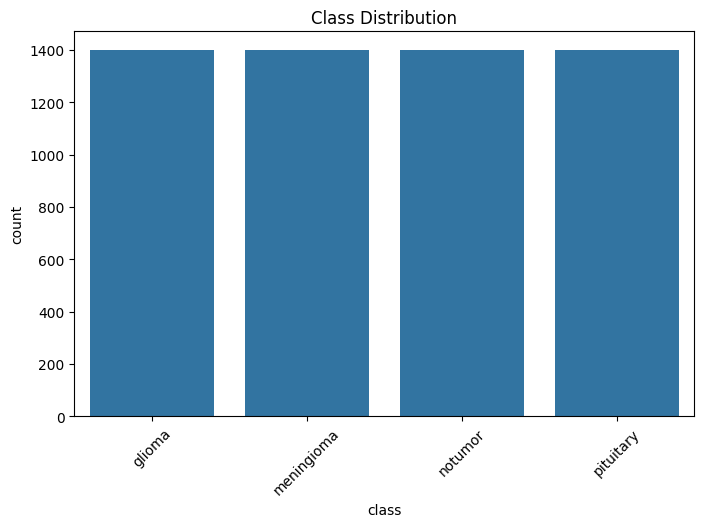

class
glioma        1400
meningioma    1400
notumor       1400
pituitary     1400
Name: count, dtype: int64


In [17]:
# ===============================
# Step 5: Class Distribution
# ===============================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="class"
)

plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()


print(df["class"].value_counts())

In [19]:
# ===============================
# Step 6: Check Corrupted Images
# ===============================

from PIL import Image
from tqdm import tqdm

corrupted_images = []

for img_path in tqdm(df["image_path"]):

    try:
        with Image.open(img_path) as img:
            img.verify()

    except Exception:
        corrupted_images.append(img_path)

print("Total Images:", len(df))
print("Corrupted Images:", len(corrupted_images))

100%|██████████| 5600/5600 [00:00<00:00, 13296.62it/s]

Total Images: 5600
Corrupted Images: 0


In [20]:
# ===============================
# Step 7: Train Validation Split
# ===============================

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)


print("Training Images:", len(train_df))
print("Validation Images:", len(val_df))


print("\nTraining Class Distribution")
print(train_df["class"].value_counts())


print("\nValidation Class Distribution")
print(val_df["class"].value_counts())

Training Images: 4480
Validation Images: 1120

Training Class Distribution
class
pituitary     1120
notumor       1120
glioma        1120
meningioma    1120
Name: count, dtype: int64

Validation Class Distribution
class
glioma        280
meningioma    280
pituitary     280
notumor       280
Name: count, dtype: int64


In [21]:
# ===============================
# Step 8: Image Transformation
# ===============================

from torchvision import transforms


train_transform = transforms.Compose([

    # Resize image
    transforms.Resize((224,224)),

    # Data Augmentation
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05,0.05)
    ),

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize for pretrained models
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


print("Transformations created successfully!")

Transformations created successfully!


In [22]:
# ===============================
# Step 9: Custom PyTorch Dataset
# ===============================

from torch.utils.data import Dataset
from PIL import Image


class BrainTumorDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform


    def __len__(self):

        return len(self.dataframe)


    def __getitem__(self, index):

        # Image path
        img_path = self.dataframe.iloc[index]["image_path"]

        # Label
        label = self.dataframe.iloc[index]["label"]


        # Open image
        image = Image.open(img_path)


        # Convert grayscale MRI to RGB
        image = image.convert("RGB")


        # Apply transformation
        if self.transform:
            image = self.transform(image)


        return image, label



print("Dataset class created successfully!")

Dataset class created successfully!


In [25]:
# ===============================
# Step 9.1: Combine Full Dataset
# ===============================

all_data = []

folders = {
    "Training": train_path,
    "Testing": test_path
}

for split_name, split_path in folders.items():

    for class_name in sorted(os.listdir(split_path)):

        class_folder = os.path.join(split_path, class_name)

        if not os.path.isdir(class_folder):
            continue

        for img_name in os.listdir(class_folder):

            if img_name.lower().endswith((".jpg", ".jpeg", ".png")):

                img_path = os.path.join(class_folder, img_name)

                all_data.append({
                    "image_path": img_path,
                    "class": class_name,
                    "source_split": split_name
                })

full_df = pd.DataFrame(all_data)

print("Total Images:", len(full_df))
print("\nClass Distribution:")
print(full_df["class"].value_counts())

print("\nSource Distribution:")
print(full_df["source_split"].value_counts())

full_df.head()

Total Images: 7200

Class Distribution:
class
glioma        1800
meningioma    1800
notumor       1800
pituitary     1800
Name: count, dtype: int64

Source Distribution:
source_split
Training    5600
Testing     1600
Name: count, dtype: int64


,image_path,class,source_split
0,/content/brain_tumor_dataset/Training/glioma/T...,glioma,Training
1,/content/brain_tumor_dataset/Training/glioma/T...,glioma,Training
2,/content/brain_tumor_dataset/Training/glioma/T...,glioma,Training
3,/content/brain_tumor_dataset/Training/glioma/T...,glioma,Training
4,/content/brain_tumor_dataset/Training/glioma/T...,glioma,Training


In [29]:
# ===============================
# Step 9.2: Create Labels
# ===============================

class_names = sorted(full_df["class"].unique())

class_to_label = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

full_df["label"] = full_df["class"].map(class_to_label)

print("Class Mapping:")
print(class_to_label)

full_df

Class Mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


,image_path,class,source_split,label
0,/content/brain_tumor_dataset/Training/glioma/T...,glioma,Training,0
1,/content/brain_tumor_dataset/Training/glioma/T...,glioma,Training,0
2,/content/brain_tumor_dataset/Training/glioma/T...,glioma,Training,0
3,/content/brain_tumor_dataset/Training/glioma/T...,glioma,Training,0
4,/content/brain_tumor_dataset/Training/glioma/T...,glioma,Training,0
...,...,...,...,...
7195,/content/brain_tumor_dataset/Testing/pituitary...,pituitary,Testing,3
7196,/content/brain_tumor_dataset/Testing/pituitary...,pituitary,Testing,3
7197,/content/brain_tumor_dataset/Testing/pituitary...,pituitary,Testing,3
7198,/content/brain_tumor_dataset/Testing/pituitary...,pituitary,Testing,3


In [30]:
# ===============================
# Step 9.3: Check Corrupted Images
# ===============================

corrupted_images = []

for img_path in tqdm(full_df["image_path"]):

    try:
        with Image.open(img_path) as img:
            img.verify()

    except Exception:
        corrupted_images.append(img_path)

print("Total Images:", len(full_df))
print("Corrupted Images:", len(corrupted_images))

100%|██████████| 7200/7200 [00:01<00:00, 4200.79it/s]

Total Images: 7200
Corrupted Images: 0


In [31]:
# ===============================
# Step 9.4: Train / Val / Test Split
# ===============================

train_df, temp_df = train_test_split(
    full_df,
    test_size=0.20,
    random_state=42,
    stratify=full_df["label"]
)

In [32]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

In [33]:
print("Total Images:", len(full_df))
print("Training Images:", len(train_df))
print("Validation Images:", len(val_df))
print("Testing Images:", len(test_df))

Total Images: 7200
Training Images: 5760
Validation Images: 720
Testing Images: 720


In [34]:
print("\nTRAIN:")
print(train_df["class"].value_counts())

print("\nVALIDATION:")
print(val_df["class"].value_counts())

print("\nTEST:")
print(test_df["class"].value_counts())


TRAIN:
class
glioma        1440
meningioma    1440
notumor       1440
pituitary     1440
Name: count, dtype: int64

VALIDATION:
class
glioma        180
pituitary     180
notumor       180
meningioma    180
Name: count, dtype: int64

TEST:
class
glioma        180
pituitary     180
meningioma    180
notumor       180
Name: count, dtype: int64


In [35]:
# ===============================
# Step 10.1: PyTorch Dataset Class
# ===============================

from torch.utils.data import Dataset
from PIL import Image


class BrainTumorDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform


    def __len__(self):

        return len(self.dataframe)


    def __getitem__(self, index):

        img_path = self.dataframe.iloc[index]["image_path"]

        label = self.dataframe.iloc[index]["label"]


        # Load image
        image = Image.open(img_path)


        # MRI images are grayscale, convert to RGB
        image = image.convert("RGB")


        # Apply preprocessing
        if self.transform:
            image = self.transform(image)


        return image, label


print("Dataset class created!")

Dataset class created!


In [36]:
# ===============================
# Create Dataset Objects
# ===============================

train_dataset = BrainTumorDataset(
    train_df,
    transform=train_transform
)


val_dataset = BrainTumorDataset(
    val_df,
    transform=val_transform
)


test_dataset = BrainTumorDataset(
    test_df,
    transform=val_transform
)


print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 5760
Validation: 720
Test: 720


In [37]:
image, label = train_dataset[0]

print("Image Shape:", image.shape)
print("Label:", label)

Image Shape: torch.Size([3, 224, 224])
Label: 0


In [38]:
# ===============================
# Step 11: DataLoader
# ===============================

from torch.utils.data import DataLoader


batch_size = 32


train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)


val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)


test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)


print("DataLoaders created successfully!")

DataLoaders created successfully!


In [39]:
images, labels = next(iter(train_loader))


print("Batch Image Shape:", images.shape)
print("Batch Labels Shape:", labels.shape)
print("Labels:", labels[:10])

Batch Image Shape: torch.Size([32, 3, 224, 224])
Batch Labels Shape: torch.Size([32])
Labels: tensor([0, 1, 2, 2, 1, 2, 0, 0, 3, 2])


In [61]:
# ===============================
# Step 12: Build EfficientNet-B2
#        + SVM
# ===============================

import torch
import torch.nn as nn
from torchvision import models
from sklearn.svm import SVC

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load pretrained EfficientNet-B2
# CHANGED: B1 → B2
weights = models.EfficientNet_B2_Weights.DEFAULT
model = models.efficientnet_b2(weights=weights)

# Remove final classifier
num_features = model.classifier[1].in_features
model.classifier = nn.Identity()

# Move model to GPU/CPU
model = model.to(device)
model.eval()

print("EfficientNet-B2 feature size:", num_features)
print(model.classifier)

Using device: cpu
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 135MB/s]


EfficientNet-B2 feature size: 1408
Identity()


In [62]:
# ===============================
# Step 13: Extract Features
# ===============================

import numpy as np

def extract_features(model, dataloader, device):
    features = []
    labels = []

    model.eval()

    with torch.no_grad():
        for images, targets in dataloader:

            images = images.to(device)

            output = model(images)

            features.append(output.cpu().numpy())
            labels.append(targets.numpy())

    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)

    return features, labels


X_train_features, y_train = extract_features(
    model,
    train_loader,
    device
)

X_test_features, y_test = extract_features(
    model,
    test_loader,
    device
)

print("Training features:", X_train_features.shape)
print("Testing features:", X_test_features.shape)

Training features: (5760, 1408)
Testing features: (720, 1408)


In [63]:
# ===============================
# Step 14: Train SVM
# ===============================

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

# Create SVM classifier
svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

# Train SVM
svm.fit(X_train_scaled, y_train)

print("SVM training completed.")

SVM training completed.


In [64]:
# ===============================
# Step 15: Evaluate SVM
# ===============================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Prediction
y_pred = svm.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("SVM Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

SVM Accuracy: 0.9611111111111111

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       180
           1       0.91      0.95      0.93       180
           2       0.98      0.98      0.98       180
           3       0.98      0.98      0.98       180

    accuracy                           0.96       720
   macro avg       0.96      0.96      0.96       720
weighted avg       0.96      0.96      0.96       720


Confusion Matrix:
[[167  11   2   0]
 [  5 171   1   3]
 [  1   2 177   0]
 [  0   3   0 177]]
